## SVM Fundamentals

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

In [36]:
from sklearn.datasets import make_blobs
x, y = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    cluster_std=1.35,
    random_state=42
)

## Imports

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


## Split the data before fitting the scaler

In [38]:
X_train,X_test,y_train,y_test=train_test_split(
     x,y,
     test_size=0.25,
     stratify=y,
     random_state=42
)

## Building of Pipeline

In [39]:
model=Pipeline(steps=[
     ("scaler",StandardScaler()),
     ("svm",SVC(kernel="linear",C=1.0))
])

## Model train and Evaluation

In [40]:
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
print("Training accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing accuracy :", accuracy_score(y_test, y_test_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred))

Training accuracy: 1.0
Testing accuracy : 1.0

Confusion matrix:
[[25  0]
 [ 0 25]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



## Extraction of Scaler and SVM

In [41]:
## Scale data
scaler = model.named_steps["scaler"]

## SVM Parameters
svm = model.named_steps["svm"]

## Scale Training Data
X_train_scaled = scaler.transform(X_train)

## Print SVM Parameters
print("\nWeight vector:", svm.coef_[0])
print("Intercept:", svm.intercept_[0])
print("Number of support vectors:", svm.n_support_)
print("Total support vectors:", len(svm.support_vectors_))


Weight vector: [ 1.14633431 -0.94187867]
Intercept: 0.1719688692498287
Number of support vectors: [3 2]
Total support vectors: 5


## Creation of Mesh Grid

In [42]:
## determine the plot boundaries
x_min, x_max = x[:, 0].min() - 1.5, x[:, 0].max() + 1.5
y_min, y_max = x[:, 1].min() - 1.5, x[:, 1].max() + 1.5

## Create a gird of 500 x 500 = 250000
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

## Convert the grid into shape (250000,2)
grid_original = np.c_[xx.ravel(), yy.ravel()]

## Compute Decision Function

In [43]:
## Compute the equation f(x) = w^t.x+b
decision_scores = model.decision_function(grid_original)

## then ir reshape the grid from (250000,2) to 500 x 500
decision_scores = decision_scores.reshape(xx.shape)

## Convert the Support Vectors to orginal Scale

In [44]:
support_vectors_original = scaler.inverse_transform(
    svm.support_vectors_
)

## Data Visualization

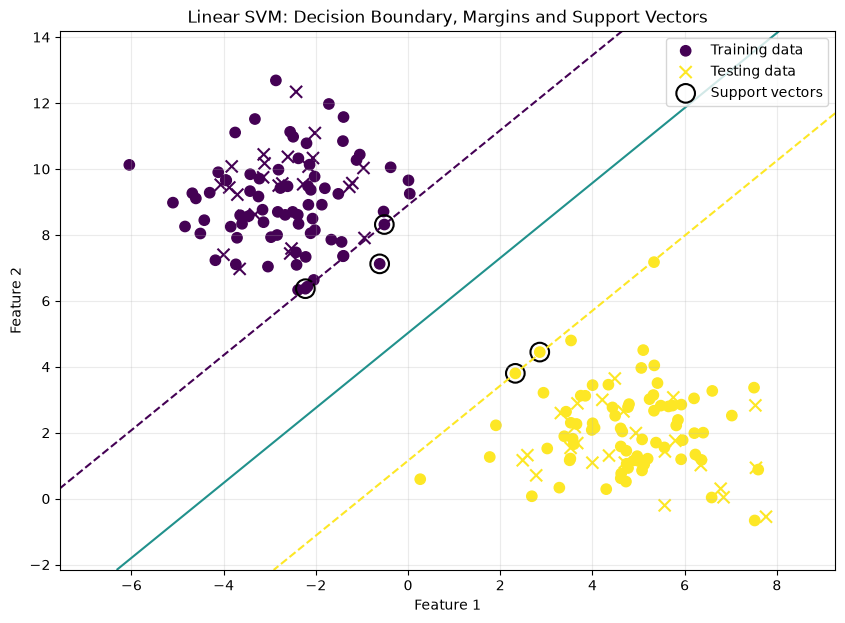

In [45]:
plt.figure(figsize=(10, 7))
plt.scatter(
    X_train[:, 0],X_train[:, 1],
    c=y_train,s=55,label="Training data"
)
plt.scatter(
    X_test[:, 0],X_test[:, 1],
    c=y_test,marker="x",s=75,label="Testing data"
)
# Draw -1 margin, 0 boundary, and +1 margin
plt.contour(
    xx,yy,decision_scores,
    levels=[-1, 0, 1],linestyles=["--", "-", "--"]
)
plt.scatter(
    support_vectors_original[:, 0],
    support_vectors_original[:, 1],
    s=180,facecolors="none",edgecolors="black",
    linewidths=1.5,label="Support vectors"
)
plt.title("Linear SVM: Decision Boundary, Margins and Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Hinge-loss Implementation

## Import Library

In [46]:
import numpy as np

## Define the Function of Hinge Loss

In [47]:
def hinge_loss(X: np.ndarray,y: np.ndarray,
    weights: np.ndarray,bias: float
) -> float:  ## x- feature matrix 
          ## y- target label
          ## weights - SVM weight vectors
          ## bias - the intercept term
          ## float means return a single number
     """ 
    Calculate mean hinge loss.

    Expected target labels:
        -1 and +1
    """ ## Function Documentation (Doc String)
     ## Check the label
     if(set(np.unique(y))-{-1,1}):
          raise ValueError("Hinge-loss labels must be encoded as -1 and +1.")
     scores = X @ weights + bias ## Compute Score
     losses = np.maximum(0, 1 - y * scores)  ## Compute hinge Loss
     return float(np.mean(losses))  ## Compute mean loss

## Create a Example Dataset

In [48]:
## Feature Matrix
x_eg = np.array([
    [2.0, 1.0],
    [1.0, 2.0],
    [-1.0, -1.0],
    [-2.0, -1.0]
])
## Target Label
y_eg = np.array([1, 1, -1, -1])
weights = np.array([0.8, 0.6])
bias = 0.0

loss = hinge_loss(
    X=x_eg,
    y=y_eg,
    weights=weights,
    bias=bias
)

print("Mean hinge loss:", loss)

Mean hinge loss: 0.0


## Comparison of C values (Regularization Paramter)

In [49]:
result=[]
for c_value in [0.01, 0.1, 1, 10, 100]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=c_value))
    ])

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    support_count = len(
        model.named_steps["svm"].support_vectors_
    )
    result.append({
        "C": c_value,
        "Train Accuracy": round(train_score, 3),
        "Test Accuracy": round(test_score, 3),
        "Support Vectors": support_count
    })

# Create DataFrame
results_df = pd.DataFrame(result)

print(results_df)

        C  Train Accuracy  Test Accuracy  Support Vectors
0    0.01             1.0            1.0               74
1    0.10             1.0            1.0               16
2    1.00             1.0            1.0                5
3   10.00             1.0            1.0                2
4  100.00             1.0            1.0                2
